In [1]:
import re
import numpy as np
from numpy import hstack
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from fuzzywuzzy import process

d:\Anaconda\Lib\site-packages\fuzzywuzzy\fuzz.py:11: UserWarning: Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning
  warnings.warn('Using slow pure-python SequenceMatcher. Install python-Levenshtein to remove this warning')


# Import data from kaggle
## And checking data

In [2]:
df = pd.read_csv("../week6_assignment/data.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21905 entries, 0 to 21904
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               21174 non-null  object 
 1   type                21905 non-null  object 
 2   genres              21536 non-null  object 
 3   releaseYear         21866 non-null  float64
 4   imdbId              20267 non-null  object 
 5   imdbAverageRating   20090 non-null  float64
 6   imdbNumVotes        20090 non-null  float64
 7   availableCountries  154 non-null    object 
dtypes: float64(3), object(5)
memory usage: 1.3+ MB


In [4]:
df.head()

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes,availableCountries
0,Ariel,movie,"Comedy, Crime, Drama",1988.0,tt0094675,7.4,9231.0,NaN
1,Shadows in Paradise,movie,"Comedy, Drama, Music",1986.0,tt0092149,7.4,8065.0,NaN
2,Forrest Gump,movie,"Drama, Romance",1994.0,tt0109830,8.8,2389767.0,NaN
3,American Beauty,movie,Drama,1999.0,tt0169547,8.3,1252125.0,NaN
4,The Fifth Element,movie,"Action, Adventure, Sci-Fi",1997.0,tt0119116,7.6,528737.0,NaN


In [5]:
len(df)

21905

In [6]:
len(df[df["type"]=="tv"])

5356

In [7]:
df[df["title"]=="Squid Game"]

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes,availableCountries
18595,Squid Game,tv,"Action, Drama, Mystery",2021.0,tt10919420,8.0,668508.0,NaN


In [8]:
df_tv = pd.DataFrame(df[df["type"]=="tv"])
df_tv.head()

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes,availableCountries
16549,NaN,tv,Comedy,1996.0,NaN,NaN,NaN,NaN
16550,Sex and the City,tv,"Comedy, Drama, Romance",1998.0,tt0159206,7.4,153408.0,NaN
16551,A Different World,tv,Comedy,1987.0,tt0092339,7.1,8573.0,NaN
16552,Martin,tv,"Comedy, Drama, Romance",1992.0,tt0103488,7.5,11565.0,NaN
16553,The Game,tv,"Comedy, Drama, Romance",2006.0,tt0772137,6.9,4998.0,NaN


In [9]:
df_tv.loc[16549]

title                    NaN
type                      tv
genres                Comedy
releaseYear           1996.0
imdbId                   NaN
imdbAverageRating        NaN
imdbNumVotes             NaN
availableCountries       NaN
Name: 16549, dtype: object

In [10]:
df_tv[df_tv["title"].isnull()]

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes,availableCountries
16549,NaN,tv,Comedy,1996.0,NaN,NaN,NaN,NaN
16657,NaN,tv,"Comedy, Drama",2003.0,NaN,NaN,NaN,NaN
16664,NaN,tv,"Drama, Comedy",2004.0,NaN,NaN,NaN,NaN
16685,NaN,tv,"Documentary, Comedy",2008.0,NaN,NaN,NaN,NaN
16692,NaN,tv,Reality,1979.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...
21895,NaN,tv,NaN,2023.0,NaN,NaN,NaN,NaN
21898,NaN,tv,NaN,2015.0,NaN,NaN,NaN,NaN
21899,NaN,tv,NaN,2009.0,NaN,NaN,NaN,NaN
21902,NaN,tv,"Animation, Crime, Mystery",1996.0,NaN,NaN,NaN,NaN


In [11]:
df_tv[df_tv["title"].isnull()].isnull().mean()

title                 1.000000
type                  0.000000
genres                0.270862
releaseYear           0.049248
imdbId                1.000000
imdbAverageRating     1.000000
imdbNumVotes          1.000000
availableCountries    0.954856
dtype: float64

In [12]:
df_tv.dropna(subset=["title"],  inplace=True)
len(df_tv)

4625

<Axes: >

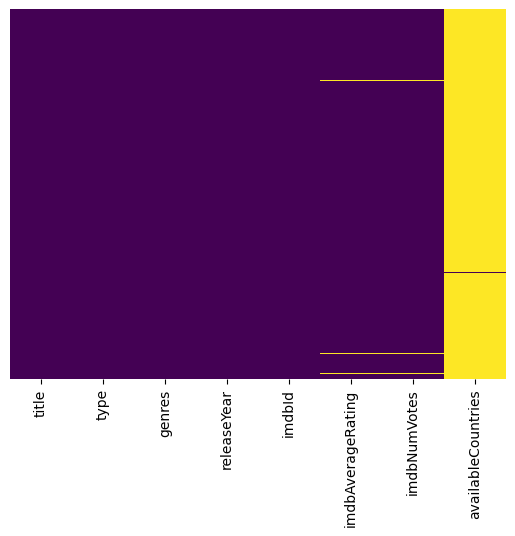

In [13]:
sns.heatmap(df_tv.isnull(), yticklabels=False, cbar=False, cmap="viridis")

In [14]:
df_tv.drop(["availableCountries"], axis=1, inplace=True)

In [15]:
df_tv["imdbNumVotes"] = df_tv.groupby("type")["imdbNumVotes"].transform(lambda x: x.fillna(x.median()))
df_tv["imdbAverageRating"] = df_tv.groupby("type")["imdbAverageRating"].transform(lambda x: x.fillna(x.median()))

<Axes: >

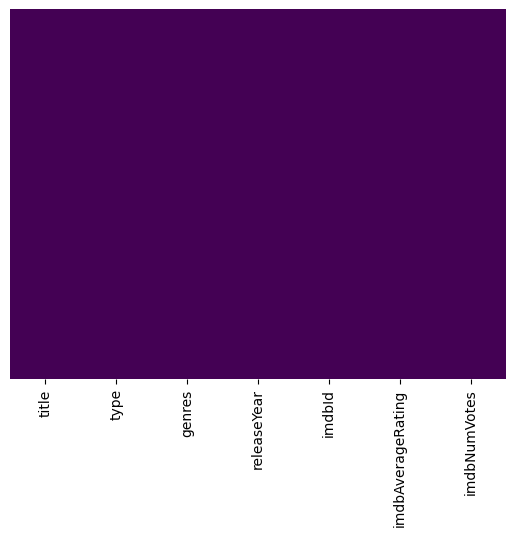

In [16]:
sns.heatmap(df_tv.isnull(), yticklabels=False, cbar=False, cmap="viridis")

In [17]:
df_tv.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4625 entries, 16550 to 21904
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              4625 non-null   object 
 1   type               4625 non-null   object 
 2   genres             4624 non-null   object 
 3   releaseYear        4624 non-null   float64
 4   imdbId             4625 non-null   object 
 5   imdbAverageRating  4625 non-null   float64
 6   imdbNumVotes       4625 non-null   float64
dtypes: float64(3), object(4)
memory usage: 289.1+ KB


In [18]:
df_tv.head()

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes
16550,Sex and the City,tv,"Comedy, Drama, Romance",1998.0,tt0159206,7.4,153408.0
16551,A Different World,tv,Comedy,1987.0,tt0092339,7.1,8573.0
16552,Martin,tv,"Comedy, Drama, Romance",1992.0,tt0103488,7.5,11565.0
16553,The Game,tv,"Comedy, Drama, Romance",2006.0,tt0772137,6.9,4998.0
16554,Avatar: The Last Airbender,tv,"Action, Adventure, Animation",2005.0,tt0417299,9.3,408831.0


In [19]:
df_tv["genres"].nunique()

397

In [20]:
df_tv["genres"].value_counts().sort_values(ascending=False).head(50)

genres
Drama                            333
Action, Adventure, Animation     323
Comedy                           211
Reality-TV                       170
Documentary                      166
Drama, Romance                   156
Comedy, Drama, Romance           149
Comedy, Drama                    139
Adventure, Animation, Comedy     139
Crime, Drama, Mystery            128
Crime, Documentary               106
Crime, Drama, Thriller            81
Action, Crime, Drama              75
Animation, Comedy, Drama          69
Comedy, Romance                   65
Game-Show, Reality-TV             57
Crime, Drama                      57
Comedy, Crime, Drama              53
Documentary, Sport                47
Drama, Thriller                   47
Drama, Mystery, Thriller          44
Action, Adventure, Drama          44
Action, Animation, Comedy         44
Animation, Comedy, Family         42
Comedy, Drama, Fantasy            36
Animation, Comedy, Fantasy        33
Animation, Family              

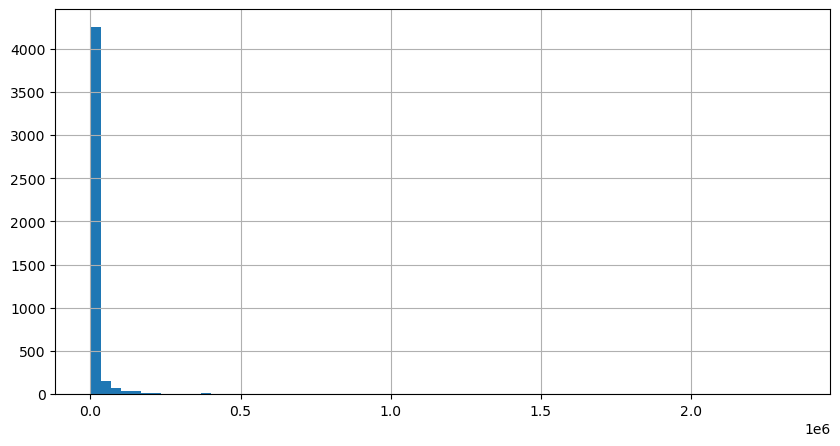

In [21]:
plt.figure(figsize=(10,5))
ax =df_tv['imdbNumVotes'].hist(bins=70)


<Axes: >

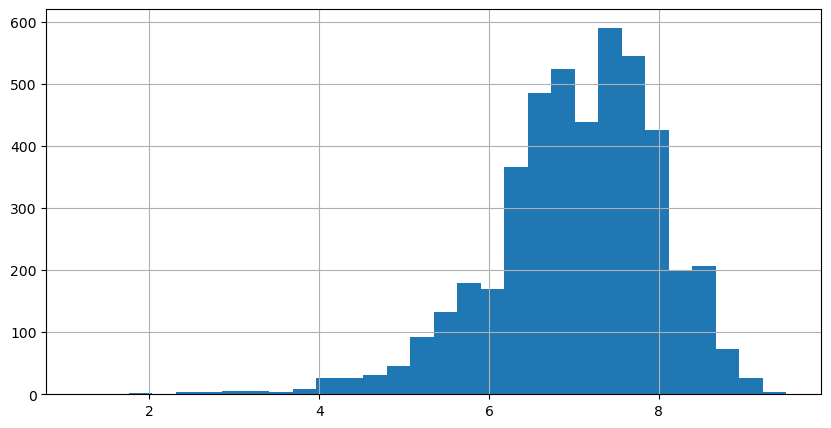

In [22]:
plt.figure(figsize=(10,5))
df_tv['imdbAverageRating'].hist(bins=30)

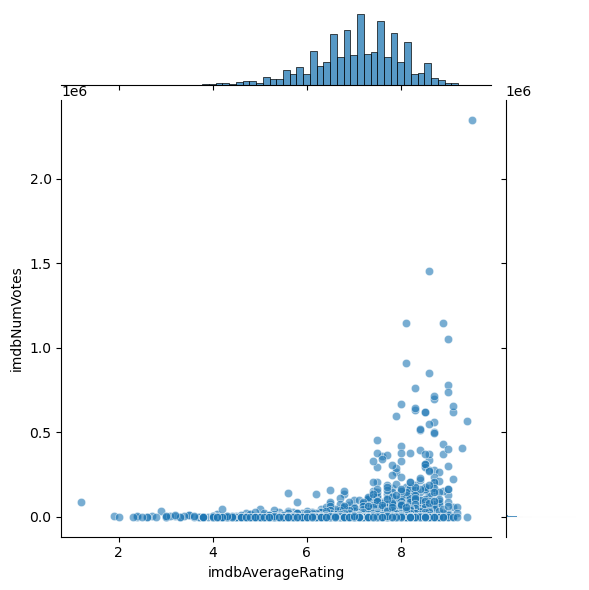

In [23]:
sns.jointplot(x="imdbAverageRating", y="imdbNumVotes", data=df_tv, alpha=0.6)

In [24]:
df_tv[df_tv["genres"].isnull()]

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes
21684,Blippi's Ultimate Bounce House Challenges,tv,NaN,2024.0,tt33769880,7.1,1523.5


In [25]:
df_tv["genres"] = df_tv["genres"].fillna("Adventure, Comedy")

In [26]:
df_tv[df_tv["title"] == "Blippi's Ultimate Bounce House Challenges"]

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes
21684,Blippi's Ultimate Bounce House Challenges,tv,"Adventure, Comedy",2024.0,tt33769880,7.1,1523.5


In [27]:
df_tv.isnull().any()

title                False
type                 False
genres               False
releaseYear           True
imdbId               False
imdbAverageRating    False
imdbNumVotes         False
dtype: bool

# Normalized

In [29]:
scaler = MinMaxScaler()
df_tv[["imdbAverageRating", "imdbNumVotes"]] = scaler.fit_transform(df_tv[["imdbAverageRating", "imdbNumVotes"]])

df_tv.head()

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes
16550,Sex and the City,tv,"[Comedy, Drama, Romance]",1998.0,tt0159206,0.746988,0.065372
16551,A Different World,tv,[Comedy],1987.0,tt0092339,0.710843,0.003651
16552,Martin,tv,"[Comedy, Drama, Romance]",1992.0,tt0103488,0.759036,0.004926
16553,The Game,tv,"[Comedy, Drama, Romance]",2006.0,tt0772137,0.686747,0.002128
16554,Avatar: The Last Airbender,tv,"[Action, Adventure, Animation]",2005.0,tt0417299,0.975904,0.174219


# Multi-hot

In [28]:
df_tv["genres"] = df_tv["genres"].apply(lambda x: re.split(r",|&", x) if isinstance(x, str) else [])
df_tv.head()

,title,type,genres,releaseYear,imdbId,imdbAverageRating,imdbNumVotes
16550,Sex and the City,tv,"[Comedy, Drama, Romance]",1998.0,tt0159206,7.4,153408.0
16551,A Different World,tv,[Comedy],1987.0,tt0092339,7.1,8573.0
16552,Martin,tv,"[Comedy, Drama, Romance]",1992.0,tt0103488,7.5,11565.0
16553,The Game,tv,"[Comedy, Drama, Romance]",2006.0,tt0772137,6.9,4998.0
16554,Avatar: The Last Airbender,tv,"[Action, Adventure, Animation]",2005.0,tt0417299,9.3,408831.0


In [ ]:
genres_seperate = set(g for G in df_tv["genres"] for g in G)

for g in genres_seperate:
    df_tv[g] = df_tv["genres"].transform(lambda x: int(g in x))

genre_rate_matrix = pd.DataFrame(df_tv.drop(["type", "genres", "releaseYear", "imdbId", "title"], axis=1)).reset_index()
clean_df = pd.DataFrame(df_tv.drop(["type", "genres", "releaseYear", "imdbId"], axis=1)).reset_index()

In [32]:
clean_df.head()

,index,title,imdbAverageRating,imdbNumVotes,Horror,Biography,Romance,Fantasy,Thriller,Romance,...,Mystery,Western,Comedy,Kids,Animation,Sci-Fi,Adventure,Comedy,Game-Show,History
0,16550,Sex and the City,0.746988,0.065372,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,16551,A Different World,0.710843,0.003651,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,16552,Martin,0.759036,0.004926,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,16553,The Game,0.686747,0.002128,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,16554,Avatar: The Last Airbender,0.975904,0.174219,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [33]:
genre_rate_matrix.drop("index", axis=1, inplace=True)
clean_df.drop("index", axis=1, inplace=True)

In [47]:
genre_rate_matrix.head()

,imdbAverageRating,imdbNumVotes,Horror,Biography,Romance,Fantasy,Thriller,Romance,Adventure,Family,...,Mystery,Western,Comedy,Kids,Animation,Sci-Fi,Adventure,Comedy,Game-Show,History
0,0.746988,0.065372,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0.710843,0.003651,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0.759036,0.004926,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.686747,0.002128,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0.975904,0.174219,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


# Trying to add weights

In [58]:
n_genre = genre_rate_matrix.shape[1] - 2
weight_vector = np.concatenate([np.ones(n_genre), np.array([0.6, 0.7])])

weighted_matrix = genre_rate_matrix.values * weight_vector

In [59]:
genre_rate_matrix.head()

,imdbAverageRating,imdbNumVotes,Horror,Biography,Romance,Fantasy,Thriller,Romance,Adventure,Family,...,Mystery,Western,Comedy,Kids,Animation,Sci-Fi,Adventure,Comedy,Game-Show,History
0,0.746988,0.065372,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0.710843,0.003651,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0.759036,0.004926,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,0.686747,0.002128,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,0.975904,0.174219,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


# Cosine Similarity

In [60]:
cosine_sim = cosine_similarity(weighted_matrix)

In [61]:
cosine_sim[0]

array([1.        , 0.6612477 , 0.99946973, ..., 0.16114724, 0.16543035,
       0.43179076])

In [62]:
len(cosine_sim)

4625

In [64]:
def movie_finder(title):
    all_titles = clean_df["title"].tolist()
    closest_match  = process.extractOne(title, all_titles)
    return closest_match[0]

In [65]:
title = movie_finder("squid game")
title

'Squid Game'

In [66]:
movie_idx = dict(zip(clean_df["title"], list(clean_df.index)))
idx = movie_idx[title]
print(f"Movie index for squid game: {idx}")

Movie index for squid game: 1969


In [67]:
n_recommendations = 8
sim_scores = list(enumerate(cosine_sim[idx]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
sim_scores = sim_scores[1:(n_recommendations+1)]
sim_scores

[(1001, 0.9919243676377127),
 (617, 0.990102799694041),
 (2986, 0.9892610583459203),
 (2201, 0.9889210941767153),
 (2693, 0.988841608606881),
 (2467, 0.9885879902037069),
 (3006, 0.8436408979373484),
 (1568, 0.8418931313674614)]

In [68]:
similar_movies = [i[0] for i in sim_scores]
similar_movies

[1001, 617, 2986, 2201, 2693, 2467, 3006, 1568]

In [69]:
print(f"You watched {title}")
clean_df["title"].iloc[similar_movies]

You watched Squid Game


1001               Designated Survivor
617                        Black Doves
2986                      Little Women
2201                The Good Detective
2693                       The Tourist
2467                           Jirisan
3006    Military Prosecutor Do Bae Man
1568                    Undercover Law
Name: title, dtype: object

In [70]:
def get_content_based_recommendations(title_str,  n_recommendations=8):
    title = movie_finder(title_str)
    idx = movie_idx[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:(n_recommendations+1)]
    similar_movies = [i[0] for i in sim_scores]
    print(f"Because you watched {title}. Here's some recommendations that you might like: ")
    print(clean_df["title"].iloc[similar_movies])

In [71]:
get_content_based_recommendations("Squid Game", 10)

Because you watched Squid Game. Here's some recommendations that you might like: 
1001               Designated Survivor
617                        Black Doves
2986                      Little Women
2201                The Good Detective
2693                       The Tourist
2467                           Jirisan
3006    Military Prosecutor Do Bae Man
1568                    Undercover Law
242                    The Mafia Dolls
1187                         La Piloto
Name: title, dtype: object


In [76]:
check =  movie_finder("La Piloto")
idx = movie_idx[check]
clean_df.loc[idx]

title                La Piloto
imdbAverageRating     0.542169
imdbNumVotes          0.000172
Horror                       0
 Biography                   0
 Romance                     0
 Fantasy                     0
Thriller                     0
Romance                      0
Adventure                    0
Family                       0
Music                        0
 Family                      0
 Talk-Show                   0
Game-Show                    0
History                      0
Biography                    0
 Action                      0
 Animation                   0
Drama                        0
 Musical                     0
 Sport                       0
Documentary                  0
Reality-TV                   0
Sci-Fi                       0
Action                       0
 Documentary                 0
Talk-Show                    0
 Drama                       1
Sport                        0
Fantasy                      0
 Crime                       0
 News   

In [ ]:
df_tv["genres"] = pd.DataFrame(df_tv["genres"].apply(lambda x: x.split(",")))
df_tv.head()

In [ ]:
mlb = MultiLabelBinarizer()
genre_list = pd.DataFrame(mlb.fit_transform(df_tv["genres"]), columns=mlb.classes_, index=df_tv.index)
genre_list

In [ ]:
df_tv = pd.concat([df_tv, genre_list], axis=1)
df_tv

In [ ]:
df_tv.head()

In [ ]:
df_tv.isnull().any()

In [ ]:
clean_df = pd.DataFrame(df_tv.drop(["type", "genres", "releaseYear", "imdbId"], axis=1))
clean_df.info()


In [ ]:
clean_df.head()

In [ ]:
genre_vector = clean_df.set_index("title")

genre_vector.head()